# KV Cache & Sliding Window Attention

In [1]:
import torch
import matplotlib.pyplot as plt

# Test: Basic Q, K, V
embeddings = torch.tensor([[1.0, 0.0], [0.0, 1.0], [0.0, 0.0]])
Q = embeddings
K = embeddings
V = embeddings
print("Q, K, V shape:", Q.shape)

Q, K, V shape: torch.Size([3, 2])


In [3]:
# Cache test
cache_k = None
keys = torch.randn(1, 3, 8)

keys.shape

torch.Size([1, 3, 8])

In [4]:


if cache_k is None:
    cache_k = keys
else:
    cache_k = torch.cat([cache_k, keys], dim=1)

print("Cache shape:", cache_k.shape)

Cache shape: torch.Size([1, 3, 8])


In [ ]:
# Sliding Window Cache
class SlidingWindowKVCache:
    def __init__(self, window_size=5):
        self.window_size = window_size
        print(f" windows size :{self.window_size}")
        self.cache_k = torch.zeros(window_size, 4)
        self.ptr_cur = 0
    
    def add(self, keys_new):
        num_tokens = keys_new.shape[0]
        if self.ptr_cur + num_tokens > self.window_size:
            overflow = self.ptr_cur + num_tokens - self.window_size
            self.cache_k[:-overflow] = self.cache_k[overflow:].clone()
            self.ptr_cur -= overflow
        self.cache_k[self.ptr_cur:self.ptr_cur + num_tokens] = keys_new
        self.ptr_cur += num_tokens
        return self.cache_k[:self.ptr_cur]

cache = SlidingWindowKVCache(window_size=4)
for i in range(6):
    key = torch.ones(1, 4) * (i + 1)
    k = cache.add(key)
    print(f"Step {i+1}: ptr={cache.ptr_cur}, cache={k.squeeze().tolist()}")

Step 1: ptr=1, cache=[1.0, 1.0, 1.0, 1.0]
Step 2: ptr=2, cache=[[1.0, 1.0, 1.0, 1.0], [2.0, 2.0, 2.0, 2.0]]
Step 3: ptr=3, cache=[[1.0, 1.0, 1.0, 1.0], [2.0, 2.0, 2.0, 2.0], [3.0, 3.0, 3.0, 3.0]]
Step 4: ptr=4, cache=[[1.0, 1.0, 1.0, 1.0], [2.0, 2.0, 2.0, 2.0], [3.0, 3.0, 3.0, 3.0], [4.0, 4.0, 4.0, 4.0]]
Step 5: ptr=4, cache=[[2.0, 2.0, 2.0, 2.0], [3.0, 3.0, 3.0, 3.0], [4.0, 4.0, 4.0, 4.0], [5.0, 5.0, 5.0, 5.0]]
Step 6: ptr=4, cache=[[3.0, 3.0, 3.0, 3.0], [4.0, 4.0, 4.0, 4.0], [5.0, 5.0, 5.0, 5.0], [6.0, 6.0, 6.0, 6.0]]


In [6]:
# Mask test
def create_mask(num_q, num_k, offset=0):
    row = torch.arange(num_q).unsqueeze(1)
    col = torch.arange(num_k).unsqueeze(0)
    return row + offset < col

print("No cache mask:")
print(create_mask(3, 3, 0))
print("Cache mask (offset=4):")
print(create_mask(1, 5, 4))

No cache mask:
tensor([[False,  True,  True],
        [False, False,  True],
        [False, False, False]])
Cache mask (offset=4):
tensor([[False, False, False, False, False]])


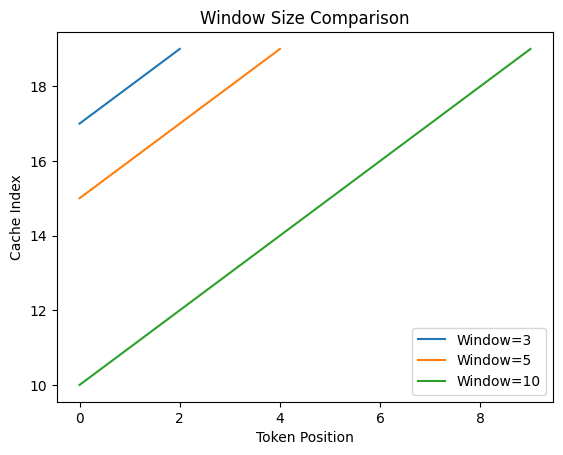

: 

In [ ]:
# Window size comparison
def simulate(ws, steps):
    cache = []
    for i in range(steps):
        cache.append(i)
        if len(cache) > ws:
            cache.pop(0)
    return cache

plt.figure()
for ws in [3, 5, 10]:
    plt.plot(simulate(ws, 20), label=f"Window={ws}")
plt.legend()
plt.title("Window Size Comparison")
plt.xlabel("Token Position")
plt.ylabel("Cache Index")
plt.show()

# Complete!